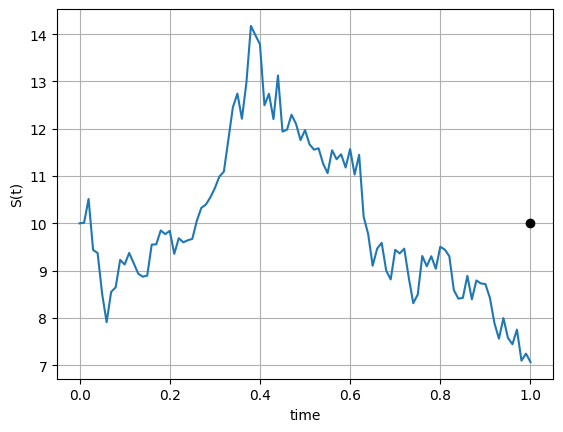

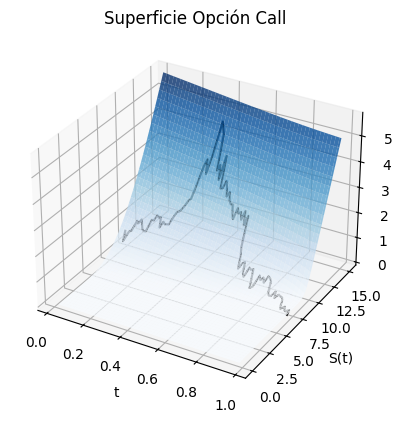

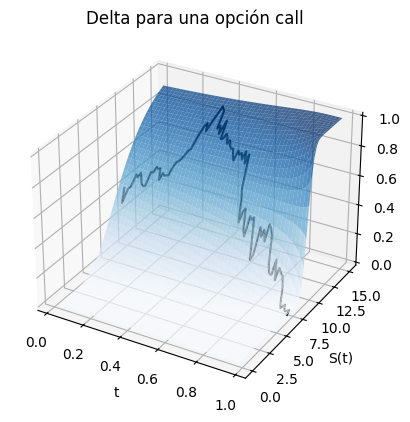

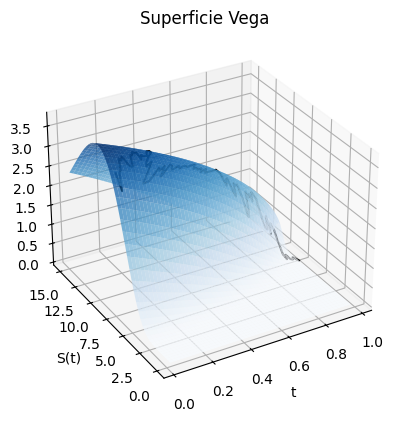

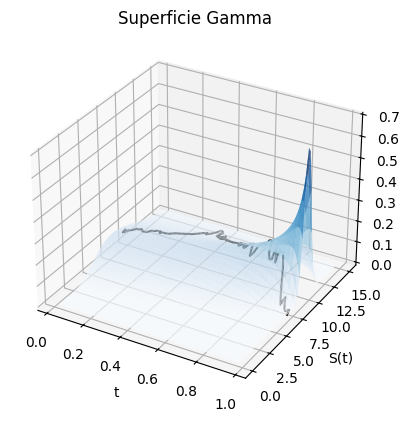

In [17]:
#%%
"""
Created on Thu Dec 12 2018
GBM path and corresponding Greeks
@author: Lech A. Grzelak
"""
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as st
import enum
from scipy.interpolate import RegularGridInterpolator

# This class defines puts and calls

class OptionType(enum.Enum):
    CALL = 1.0
    PUT = -1.0

def GeneratePathsGBM(NoOfPaths,NoOfSteps,T,r,sigma,S_0):    
    Z = np.random.normal(0.0,1.0,[NoOfPaths,NoOfSteps])
    X = np.zeros([NoOfPaths, NoOfSteps+1])
    W = np.zeros([NoOfPaths, NoOfSteps+1])
    time = np.zeros([NoOfSteps+1])
        
    X[:,0] = np.log(S_0)
    
    dt = T / float(NoOfSteps)
    for i in range(0,NoOfSteps):

        # Making sure that samples from a normal have mean 0 and variance 1

        if NoOfPaths > 1:
            Z[:,i] = (Z[:,i] - np.mean(Z[:,i])) / np.std(Z[:,i])
        W[:,i+1] = W[:,i] + np.power(dt, 0.5)*Z[:,i]
        X[:,i+1] = X[:,i] + (r - 0.5 * sigma * sigma) * dt + sigma * (W[:,i+1]-W[:,i])
        time[i+1] = time[i] +dt
        
    # Compute exponent of ABM

    S = np.exp(X)
    paths = {"time":time,"S":S}
    return paths

# Black-Scholes call option price

def BS_Call_Put_Option_Price(CP,S_0,K,sigma,t,T,r):
    #print('Maturity T={0} and t={1}'.format(T,t))
    #print(float(sigma * np.sqrt(T-t)))
    #print('strike K ={0}'.format(K))
    K = np.array(K).reshape([len(K),1])
    d1    = (np.log(S_0 / K) + (r + 0.5 * np.power(sigma,2.0)) 
    * (T-t)) / (sigma * np.sqrt(T-t))
    d2    = d1 - sigma * np.sqrt(T-t)
    if CP == OptionType.CALL:
        value = st.norm.cdf(d1) * S_0 - st.norm.cdf(d2) * K * np.exp(-r * (T-t))
     #   print(value)
    elif CP == OptionType.PUT:
        value = st.norm.cdf(-d2) * K * np.exp(-r * (T-t)) - st.norm.cdf(-d1)*S_0
      #  print(value)
    return value

def BS_Delta(CP,S_0,K,sigma,t,T,r):
    K = np.array(K).reshape([len(K),1])
    d1    = (np.log(S_0 / K) + (r + 0.5 * np.power(sigma,2.0)) * \
             (T-t)) / (sigma * np.sqrt(T-t))
    if CP == OptionType.CALL:
        value = st.norm.cdf(d1)
    elif CP == OptionType.PUT:
       value = st.norm.cdf(d1)-1
    return value

def BS_Gamma(S_0,K,sigma,t,T,r):
    K = np.array(K).reshape([len(K),1])
    d1    = (np.log(S_0 / K) + (r + 0.5 * np.power(sigma,2.0)) * \
             (T-t)) / (sigma * np.sqrt(T-t))
    return st.norm.pdf(d1) / (S_0 * sigma * np.sqrt(T-t))

def BS_Vega(S_0,K,sigma,t,T,r):
    d1    = (np.log(S_0 / K) + (r + 0.5 * np.power(sigma,2.0)) * \
             (T-t)) / (sigma * np.sqrt(T-t))
    return S_0*st.norm.pdf(d1)*np.sqrt(T-t)


def mainCalculation():
    NoOfPaths = 50
    NoOfSteps = 100
    T         = 1.001
    r         = 0.05
    sigma     = 0.4
    s0        = 10
    K         = [10]
    pathId    = 10
    
    np.random.seed(3)
    Paths = GeneratePathsGBM(NoOfPaths,NoOfSteps,T,r,sigma,s0)
    time  = Paths["time"]
    S     = Paths["S"]
    
    # Settings for the plots    

    s0Grid     = np.linspace(s0/100.0,1.5*s0,50)
    timeGrid   = np.linspace(0.02,T-0.02,100)
    
    # Prepare the necessary lambda functions

    CallOpt   = lambda t,s0 : BS_Call_Put_Option_Price(OptionType.CALL,s0,K,sigma,t,T,r)
    PutOpt    = lambda t,s0 : BS_Call_Put_Option_Price(OptionType.PUT,s0,K,sigma,t,T,r)
    DeltaCall = lambda t,s0 : BS_Delta(OptionType.CALL,s0,K,sigma,t,T,r)
    Gamma     = lambda t,s0 : BS_Gamma(s0,K,sigma,t,T,r)
    Vega      = lambda t,s0 : BS_Vega(s0,K,sigma,t,T,r)    
    
    # Prepare empty matrices for storing the results

    callOptM   = np.zeros([len(timeGrid),len(s0Grid)])
    putOptM    = np.zeros([len(timeGrid),len(s0Grid)])
    deltaCallM = np.zeros([len(timeGrid),len(s0Grid)])
    gammaM     = np.zeros([len(timeGrid),len(s0Grid)])
    vegaM      = np.zeros([len(timeGrid),len(s0Grid)])
    TM         = np.zeros([len(timeGrid),len(s0Grid)])
    s0M        = np.zeros([len(timeGrid),len(s0Grid)])

    for i in range(0,len(timeGrid)):
        TM[i,:]         = timeGrid[i]
        s0M[i,:]        = s0Grid
        callOptM[i,:]   = CallOpt(timeGrid[i],s0Grid)
        putOptM[i,:]    = PutOpt(timeGrid[i],s0Grid)
        deltaCallM[i,:] = DeltaCall(timeGrid[i],s0Grid)
        gammaM[i,:]     = Gamma(timeGrid[i],s0Grid) 
        vegaM[i,:]      = Vega(timeGrid[i],s0Grid) 
    
    # Plot stock path

    plt.figure(1)
    plt.plot(time,  np.squeeze(S[pathId,:]))   
    plt.grid()
    plt.xlabel("time")
    plt.ylabel("S(t)")
    plt.plot(T,K,'ok')
    
    # Plot the call option surface 

    fig = plt.figure(2)
    ax = fig.add_subplot(projection='3d')
    ax.plot_surface(TM, s0M, callOptM,     cmap="Blues",
    alpha=0.8,
    edgecolor="none",
    antialiased=True
)
    plt.xlabel('t')
    plt.ylabel('S(t)')
    plt.title('Superficie Opción Call')
    Finterp = RegularGridInterpolator((timeGrid[0:],s0Grid),callOptM)
    v = np.zeros([len(time),1])
    vTemp = []
    timeTemp = []
    pathTemp = []
    for j in range(5,len(time)):
        if time[j] > timeGrid[0] and time[j] < timeGrid[-1]:
            v[j] = Finterp([time[j],S[pathId,j]])
            vTemp.append(Finterp([time[j],S[pathId,j]])[0])
            timeTemp.append(time[j])
            pathTemp.append(S[pathId,j])

    # Add the stock path to the surface 

    ax.plot3D(np.array(timeTemp),np.array(pathTemp),np.array(vTemp), 'black')
   
    
    # Plot the Delta for a call option surface    

    fig = plt.figure(4)
    ax = fig.add_subplot(projection='3d')
    ax.plot_surface(TM, s0M, deltaCallM,     cmap="Blues",
    alpha=0.75,
    edgecolor="none",
    antialiased=True
)
    plt.xlabel('t')
    plt.ylabel('S(t)')
    plt.title('Delta para una opción call')
    Finterp = RegularGridInterpolator((timeGrid[0:],s0Grid),deltaCallM)
    v = np.zeros([len(time),1])
    vTemp = []
    timeTemp = []
    pathTemp = []
    for j in range(5,len(time)):
        if time[j] > timeGrid[0] and time[j] < timeGrid[-1]:
            v[j] = Finterp([time[j],S[pathId,j]])
            vTemp.append(Finterp([time[j],S[pathId,j]])[0])
            timeTemp.append(time[j])
            pathTemp.append(S[pathId,j])

    # Add the stock path to the surface 

    ax.plot3D(np.array(timeTemp),np.array(pathTemp),np.array(vTemp), 'black')
    
    # Plot the Vega option surface.    

    fig = plt.figure(5)
    ax = fig.add_subplot(projection='3d')
    ax.plot_surface(TM, s0M, vegaM,     cmap="Blues",
    alpha=0.75,
    edgecolor="none",
    antialiased=True
)
    plt.xlabel('t')
    plt.ylabel('S(t)')
    plt.title('Superficie Vega')
    Finterp = RegularGridInterpolator((timeGrid[0:],s0Grid),vegaM)
    v = np.zeros([len(time),1])
    vTemp = []
    timeTemp = []
    pathTemp = []
    for j in range(5,len(time)):
        if time[j] > timeGrid[0] and time[j] < timeGrid[-1]:
            v[j] = Finterp([time[j],S[pathId,j]])
            vTemp.append(Finterp([time[j],S[pathId,j]])[0])
            timeTemp.append(time[j])
            pathTemp.append(S[pathId,j])

    # Add the stock path to the surface 

    ax.plot3D(np.array(timeTemp),np.array(pathTemp),np.array(vTemp), 'black')
    ax.view_init(30, -120)
    
    # Plot the Gamma option surface    

    fig = plt.figure(6)
    ax = fig.add_subplot(projection='3d')
    ax.plot_surface(TM, s0M, gammaM,     cmap="Blues",
    alpha=0.75,
    edgecolor="none",
    antialiased=True
)
    plt.xlabel('t')
    plt.ylabel('S(t)')
    plt.title('Superficie Gamma')
    Finterp = RegularGridInterpolator((timeGrid[0:],s0Grid),gammaM)
    v = np.zeros([len(time),1])
    vTemp = []
    timeTemp = []
    pathTemp = []
    for j in range(5,len(time)):
        if time[j] > timeGrid[0] and time[j] < timeGrid[-1]:
            v[j] = Finterp([time[j],S[pathId,j]])
            vTemp.append(Finterp([time[j],S[pathId,j]])[0])
            timeTemp.append(time[j])
            pathTemp.append(S[pathId,j])

    # Add the stock path to the surface

    ax.plot3D(np.array(timeTemp),np.array(pathTemp),np.array(vTemp), 'black')
    #ax.view_init(30, -120)

    plt.show()

mainCalculation()